# Brain Tumor Classification - Exploratory Data Analysis (EDA)

This notebook performs a detailed EDA to understand the dataset structure, image properties, class imbalance, and visual patterns.


In [5]:
import warnings
warnings.filterwarnings("ignore")


In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 👉 Set your dataset path here
data_dir = Path(r"C:\Users\AbdulHafeez\Brain_Tumor\extracted")

# List the 4 class folders
classes = [c.name for c in data_dir.iterdir() if c.is_dir()]
classes


['glioma', 'meningioma', 'no_tumor', 'pituitary']

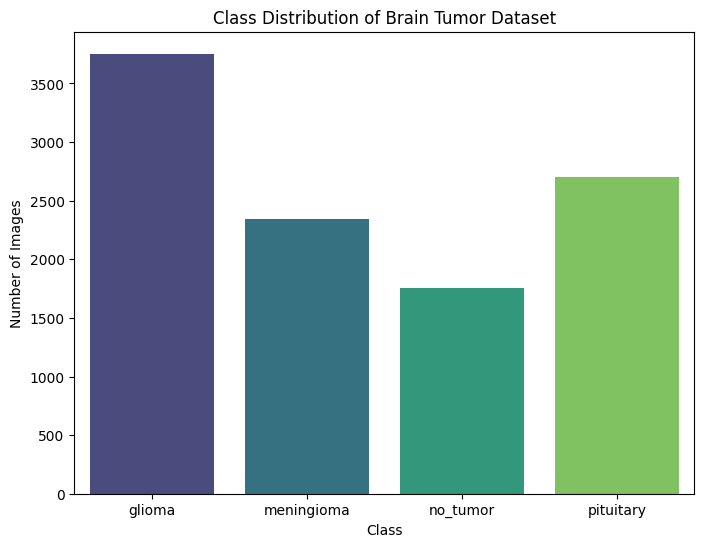

In [6]:
# Count images in each class
counts = {c: len(list((data_dir / c).glob("*.*"))) for c in classes}
df_counts = pd.DataFrame(counts.items(), columns=["Class", "Count"])

# Plot class distribution
plt.figure(figsize=(8,6))
sns.barplot(x="Class", y="Count", data=df_counts, palette="viridis")
plt.title("Class Distribution of Brain Tumor Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


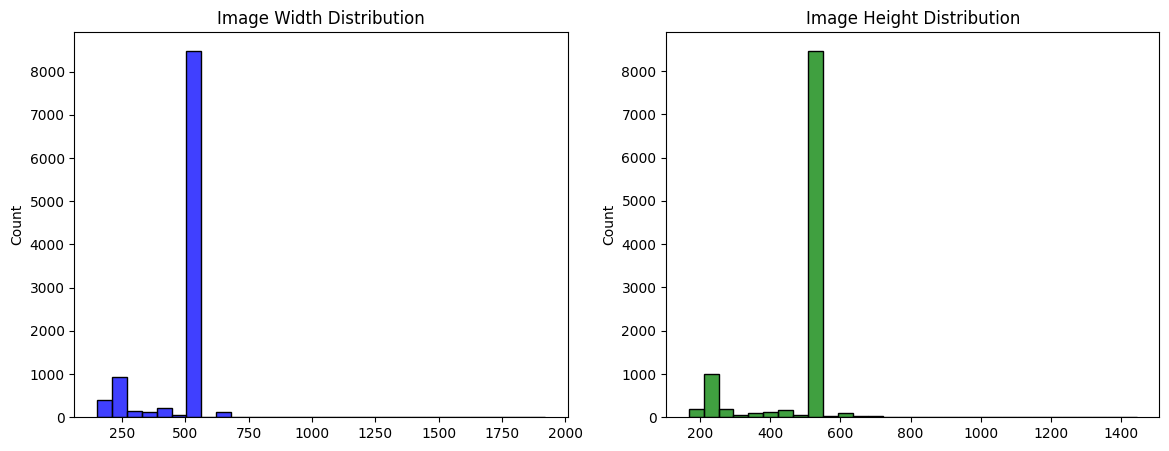

(10560, 10560)

In [7]:
# Collect image sizes for all images in dataset
widths = []
heights = []

for c in classes:
    for img_path in (data_dir / c).glob("*.*"):
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

# Plot width and height distributions
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30, color='blue')
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30, color='green')
plt.title("Image Height Distribution")

plt.show()

len(widths), len(heights)


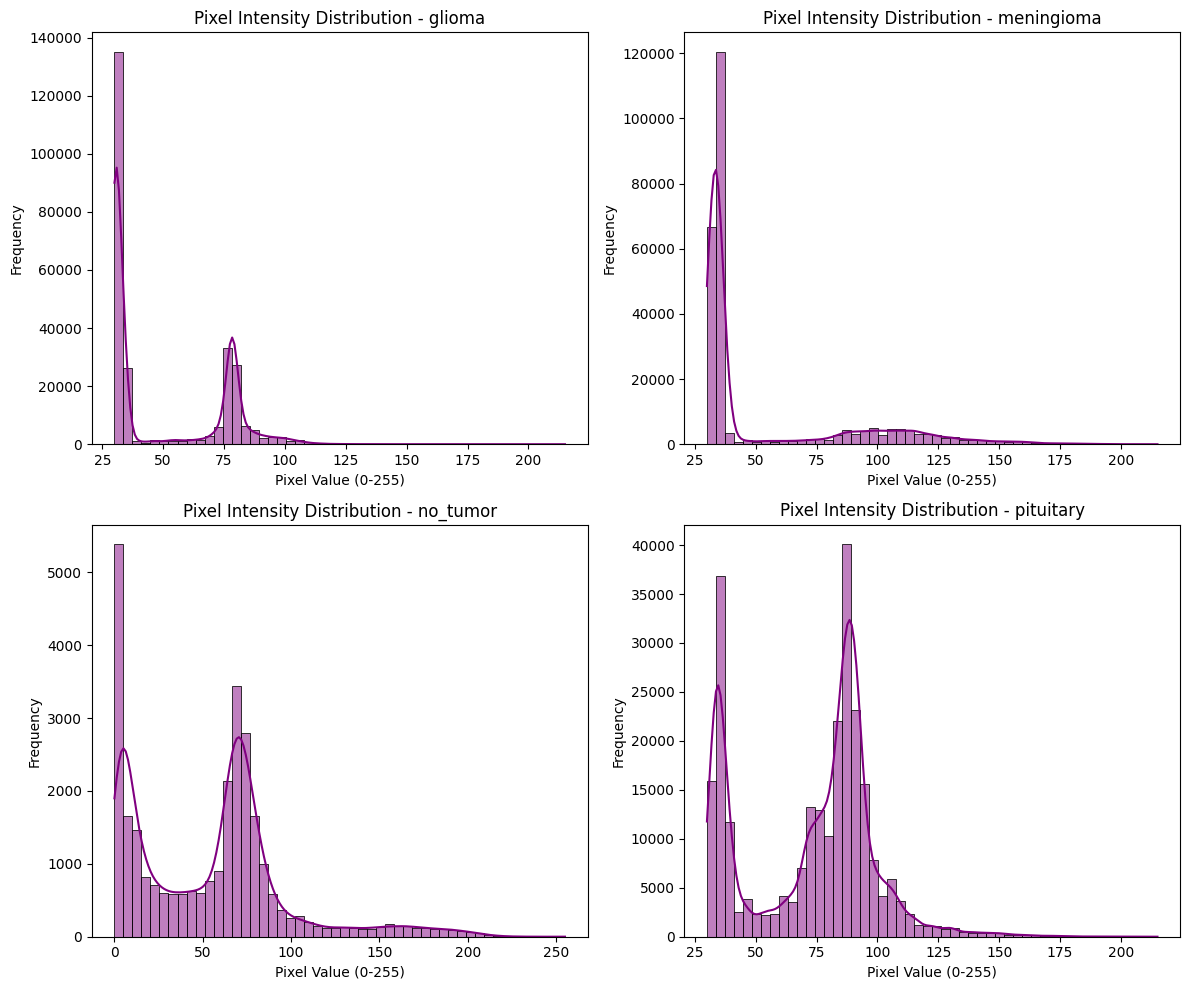

In [8]:
# Pixel intensity distribution for a random image from each class

plt.figure(figsize=(12, 10))

for i, c in enumerate(classes):
    img_path = next((data_dir / c).glob("*.*"))  # first image
    img = Image.open(img_path).convert("L")      # convert to grayscale
    arr = np.array(img).flatten()

    plt.subplot(2, 2, i+1)
    sns.histplot(arr, bins=50, kde=True, color="purple")
    plt.title(f"Pixel Intensity Distribution - {c}")
    plt.xlabel("Pixel Value (0-255)")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# EDA Summary — Brain Tumor Classification Dataset

###  1. Classes Identified
The dataset contains four categories:
- Glioma
- Meningioma
- Pituitary
- No Tumor

This makes the problem a **multi-class classification task**.

---

###  2. Class Imbalance Observed
The number of images per class is uneven:

- Glioma: 3754  
- Meningioma: 2343  
- Pituitary: 2706  
- No Tumor: 1757  

Imbalance means the model might learn biased patterns.  
We will address this using:
- Class weights  
- Data augmentation  

---

###  3. Image Size Variability
EDA shows two major size groups:
- Tumor images: mostly **512 × 512**
- No Tumor images: around **150 × 198**

Due to varying image sizes, we must **resize all images to (224, 224)** to feed into a CNN.

---

###  4. Color Mode Differences
- Many tumor images are **RGBA** (4 channels)  
- No Tumor images are **RGB** (3 channels)

We will **convert all images to RGB** before model training.

---

###  5. Pixel Intensity Distribution
MRI pixel intensities vary across classes.  
Normalization is required to:
- Improve model performance  
- Reduce contrast differences  
- Stabilize gradient updates  

We will normalize pixel values to **[0, 1]**.

---

###  6. Visual Pattern Observations
- Tumor images have distinct shapes and brighter intensity near affected regions  
- No Tumor images are more uniform  
- Pituitary tumors often appear at the base of the brain  
- Glioma and Meningioma show different texture patterns

These observations confirm that a CNN can learn useful spatial features.

---

###  Final EDA Conclusion
EDA confirms that preprocessing is required:
- Resize to (224, 224)
- Convert RGBA → RGB
- Normalize pixel values
- Use augmentation
- Use class weights

Dataset is suitable for deep learning classification using CNN and transfer learning models.

